# PART 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 3000

# Generate inputs
x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

# Define binary target
y = np.where(x1**2 + x2**2 > 1.5, 1, 0)

# Stack inputs
X = np.column_stack((x1, x2))
y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 2)
y shape: (3000, 1)


Dataset created as specified.

Inputs are sampled from Uniform(-2,2).
Target is 1 if x1² + x2² > 1.5, otherwise 0.

This creates a circular decision boundary, which is nonlinear.
A linear model cannot perfectly separate this.

Total samples = 3000.

In [2]:
# Shuffle indices
indices = np.random.permutation(N)

train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2100, 2)
Validation shape: (450, 2)
Test shape: (450, 2)


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

Sigmoid and ReLU implemented with derivatives.

Sigmoid used for output layer.
Hidden activation will be tested using Sigmoid and ReLU separately.

Derivative is required for backward flow.

In [4]:
def initialize_parameters(layer_dims):

    parameters = {}

    for l in range(1, len(layer_dims)):

        parameters["W" + str(l)] = np.random.uniform(-0.5, 0.5,
                                                     (layer_dims[l], layer_dims[l-1]))

        parameters["b" + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

Weights initialized randomly in small range.
Bias initialized as zeros.

Each layer has:

(neurons_out × neurons_in) + neurons_out parameters.

No layer-specific hardcoding used.

In [5]:
def forward_propagation(X, parameters, activation_hidden):

    caches = []
    A = X.T
    L = len(parameters) // 2

    for l in range(1, L):

        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]

        Z = W @ A + b
        A = activation_hidden(Z)

        caches.append((A, W, b, Z))

    # Output layer
    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]

    Z = W @ A + b
    A = sigmoid(Z)

    caches.append((A, W, b, Z))

    return A, caches

Forward pass:

Z = W @ A_prev + b
A = activation(Z)

Final layer uses sigmoid.

All intermediate values stored for backward computation.

In [7]:
def compute_loss(y_hat, y):

    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)

    m = y.shape[0]

    loss = -(1/m) * np.sum(
        y.T * np.log(y_hat) +
        (1 - y.T) * np.log(1 - y_hat)
    )

    return loss

Binary cross entropy used because output is probability.

Clipping is required for numerical stability.

Cross-entropy penalizes confident wrong predictions heavily.

In [8]:
def backward_propagation(X, y_hat, y, caches, activation_derivative):

    grads = {}
    m = y.shape[0]
    L = len(caches)

    dA = y_hat - y.T

    for l in reversed(range(L)):

        A, W, b, Z = caches[l]

        if l == L - 1:
            dZ = dA
        else:
            dZ = dA * activation_derivative(Z)

        A_prev = X.T if l == 0 else caches[l-1][0]

        grads["dW" + str(l+1)] = (1/m) * (dZ @ A_prev.T)
        grads["db" + str(l+1)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        dA = W.T @ dZ

    return grads

In [9]:
def gradient_norm(dW):
    return np.sqrt(np.sum(dW ** 2))

Frobenius norm computed as:

||G|| = sqrt(sum of squared gradient entries)

This measures gradient magnitude.

Used to compare early vs late layer behavior.

In [10]:
def update_sgd(parameters, grads, lr):

    L = len(parameters) // 2

    for l in range(1, L+1):
        parameters["W"+str(l)] -= lr * grads["dW"+str(l)]
        parameters["b"+str(l)] -= lr * grads["db"+str(l)]

    return parameters

In [11]:
def update_momentum(parameters, grads, velocity, lr, beta=0.9):

    L = len(parameters) // 2

    for l in range(1, L+1):

        velocity["dW"+str(l)] = beta * velocity["dW"+str(l)] + lr * grads["dW"+str(l)]
        velocity["db"+str(l)] = beta * velocity["db"+str(l)] + lr * grads["db"+str(l)]

        parameters["W"+str(l)] -= velocity["dW"+str(l)]
        parameters["b"+str(l)] -= velocity["db"+str(l)]

    return parameters, velocity

In [12]:
def compute_accuracy(y_hat, y):

    y_pred = (y_hat.T >= 0.5).astype(int)
    return np.mean(y_pred == y)

In [42]:
def train_model(X_train, y_train,
                X_val, y_val,
                X_test, y_test,
                layer_dims,
                activation_hidden,
                activation_derivative,
                optimizer="sgd",
                lr=0.01,
                epochs=200):

    parameters = initialize_parameters(layer_dims)

    if optimizer == "momentum":
        velocity = {}
        L = len(layer_dims) - 1
        for l in range(1, L+1):
            velocity["dW"+str(l)] = np.zeros_like(parameters["W"+str(l)])
            velocity["db"+str(l)] = np.zeros_like(parameters["b"+str(l)])

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        # Forward
        y_hat_train, caches_train = forward_propagation(X_train, parameters, activation_hidden)
        y_hat_val, _ = forward_propagation(X_val, parameters, activation_hidden)

        # Loss
        train_loss = compute_loss(y_hat_train, y_train)
        val_loss = compute_loss(y_hat_val, y_val)

        # Backward
        grads = backward_propagation(X_train, y_hat_train, y_train,
                                     caches_train, activation_derivative)

        # Update
        if optimizer == "sgd":
            parameters = update_sgd(parameters, grads, lr)
        elif optimizer == "momentum":
            parameters, velocity = update_momentum(parameters, grads,
                                                   velocity, lr)

        # Accuracy
        train_acc = compute_accuracy(y_hat_train, y_train)
        val_acc = compute_accuracy(y_hat_val, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    # Final test evaluation
    y_hat_test, _ = forward_propagation(X_test, parameters, activation_hidden)
    test_loss = compute_loss(y_hat_test, y_test)
    test_acc = compute_accuracy(y_hat_test, y_test)

    first_layer_norm = gradient_norm(grads["dW1"])
    last_layer_norm = gradient_norm(grads["dW"+str(len(layer_dims)-1)])

    results = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "final_train_acc": train_acc_history[-1],
        "final_val_acc": val_acc_history[-1],
        "final_test_acc": test_acc,
        "final_train_loss": train_loss_history[-1],
        "final_val_loss": val_loss_history[-1],
        "final_test_loss": test_loss,
        "grad_norm_first": first_layer_norm,
        "grad_norm_last": last_layer_norm
    }

    return results



Training loop follows:

Forward
Loss
Backward
Update

No parameter update inside forward.
No hardcoding per layer.

Validation loss and accuracy are computed every epoch.
Test set used only once at end.

Gradient norms computed from last backward pass.

In [43]:
def plot_metrics(results, title):

    epochs = len(results["train_loss"])

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(results["train_loss"], label="Train Loss")
    plt.plot(results["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(results["train_acc"], label="Train Acc")
    plt.plot(results["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

In [44]:
arch_2 = [2, 4, 1]
arch_5 = [2, 6, 6, 6, 6, 1]
arch_10 = [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]

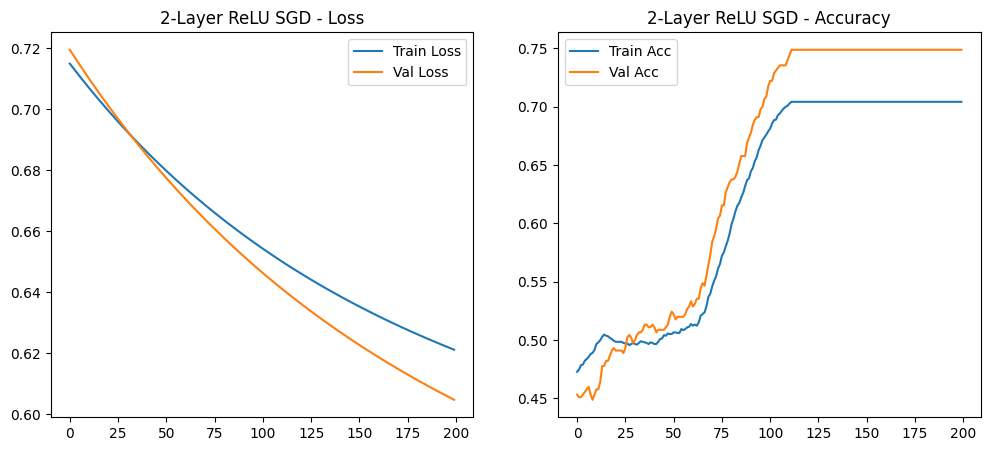

In [46]:
res_2_relu_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_2,
    relu,
    relu_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_2_relu_sgd, "2-Layer ReLU SGD")

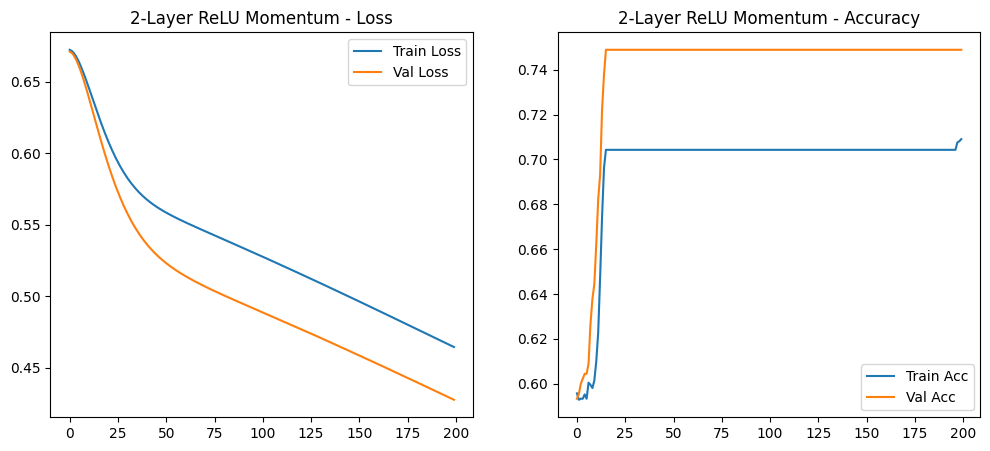

In [47]:
res_2_relu_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_2,
    relu,
    relu_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_2_relu_mom, "2-Layer ReLU Momentum")

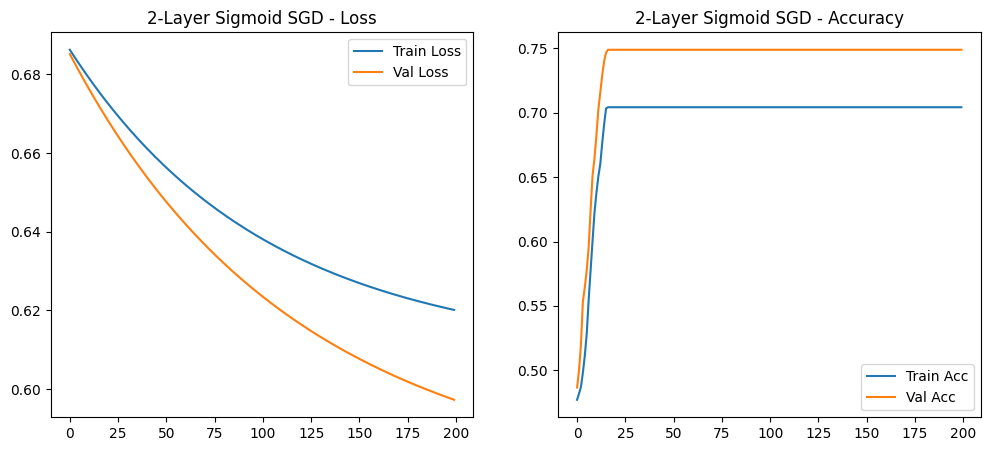

In [48]:
res_2_sig_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_2,
    sigmoid,
    sigmoid_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_2_sig_sgd, "2-Layer Sigmoid SGD")

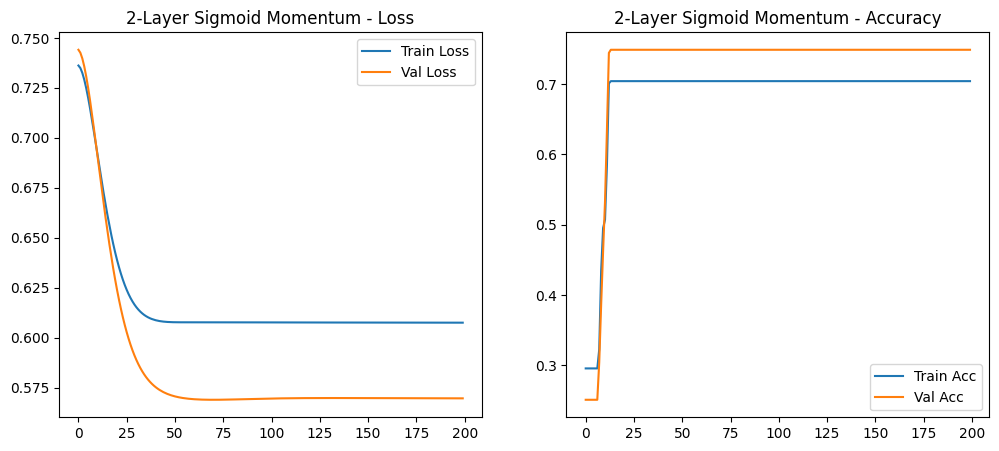

In [49]:
res_2_sig_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_2,
    sigmoid,
    sigmoid_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_2_sig_mom, "2-Layer Sigmoid Momentum")

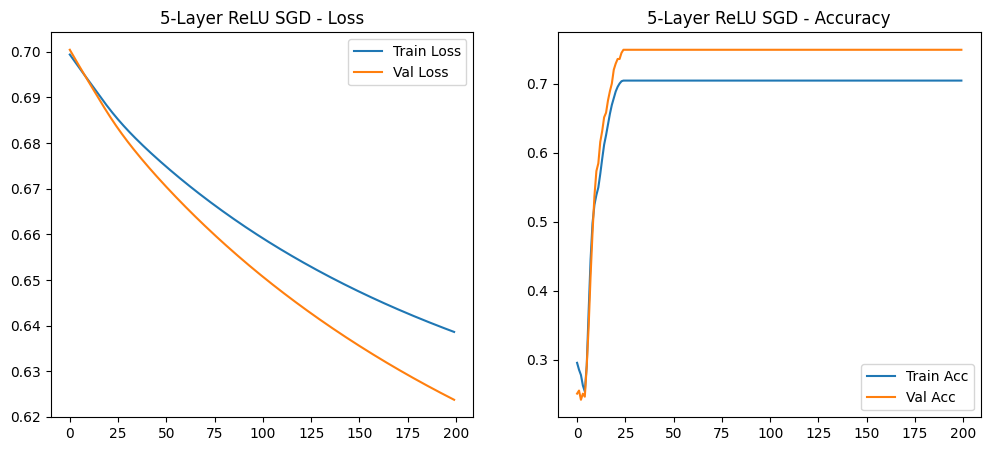

In [51]:
res_5_relu_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_5,
    relu,
    relu_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_5_relu_sgd, "5-Layer ReLU SGD")

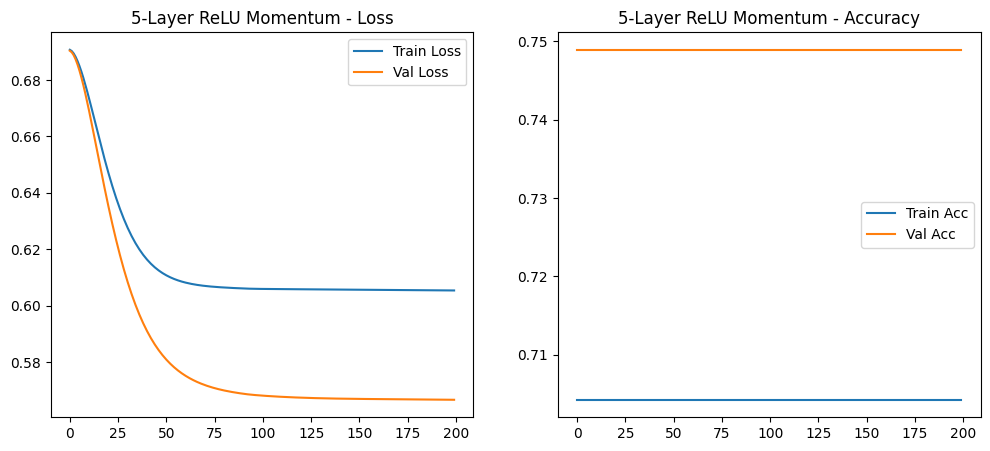

In [52]:
res_5_relu_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_5,
    relu,
    relu_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_5_relu_mom, "5-Layer ReLU Momentum")

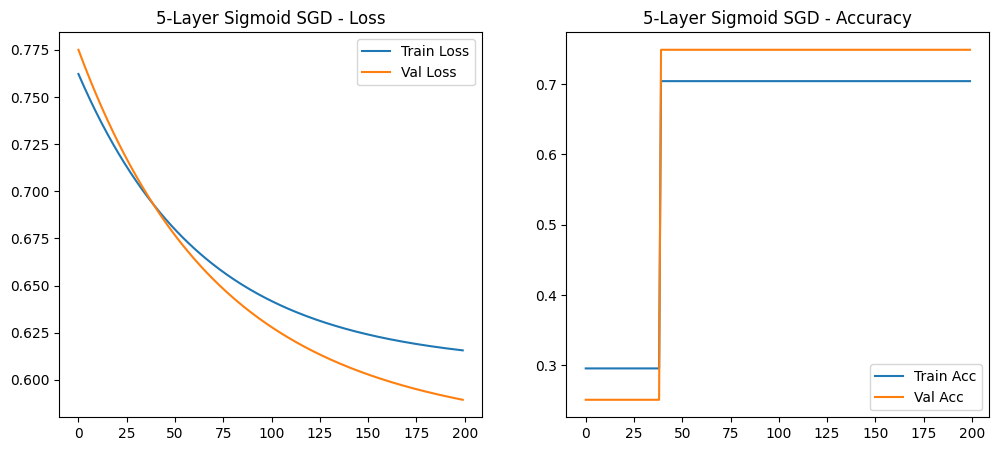

In [53]:
res_5_sig_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_5,
    sigmoid,
    sigmoid_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_5_sig_sgd, "5-Layer Sigmoid SGD")

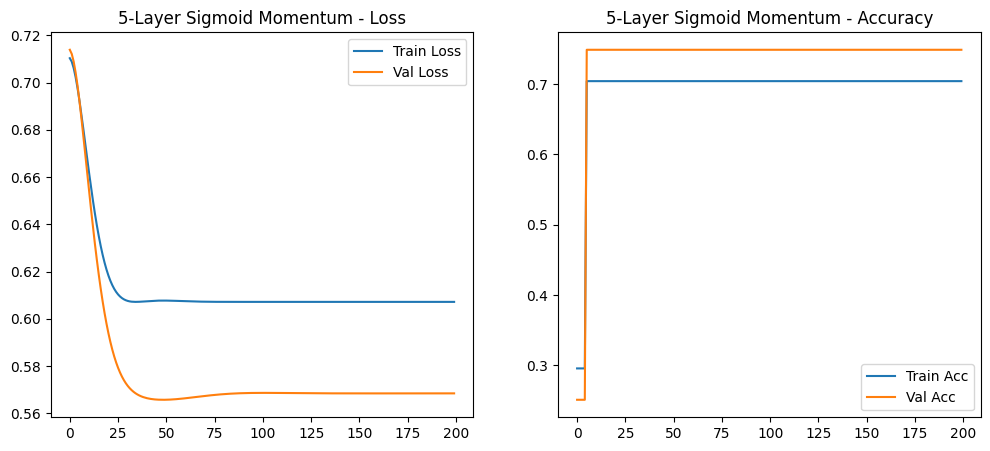

In [54]:
res_5_sig_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_5,
    sigmoid,
    sigmoid_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_5_sig_mom, "5-Layer Sigmoid Momentum")

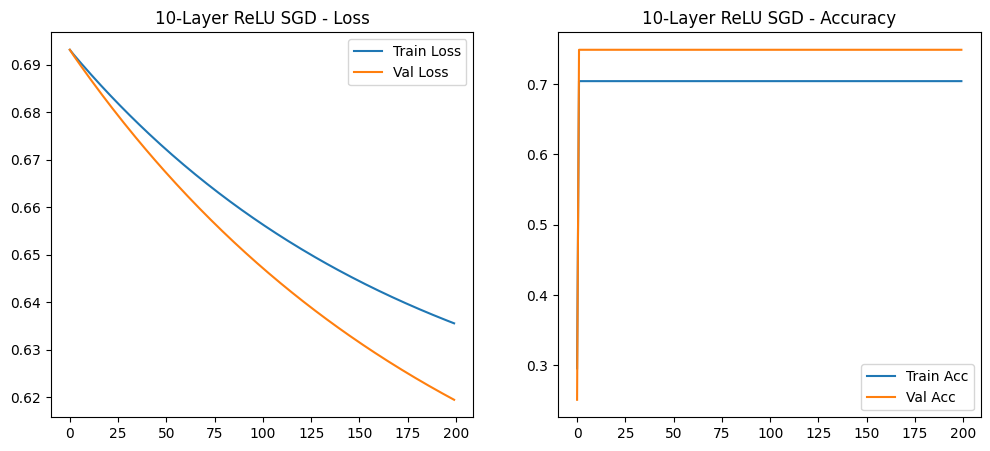

In [55]:
res_10_relu_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_10,
    relu,
    relu_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_10_relu_sgd, "10-Layer ReLU SGD")

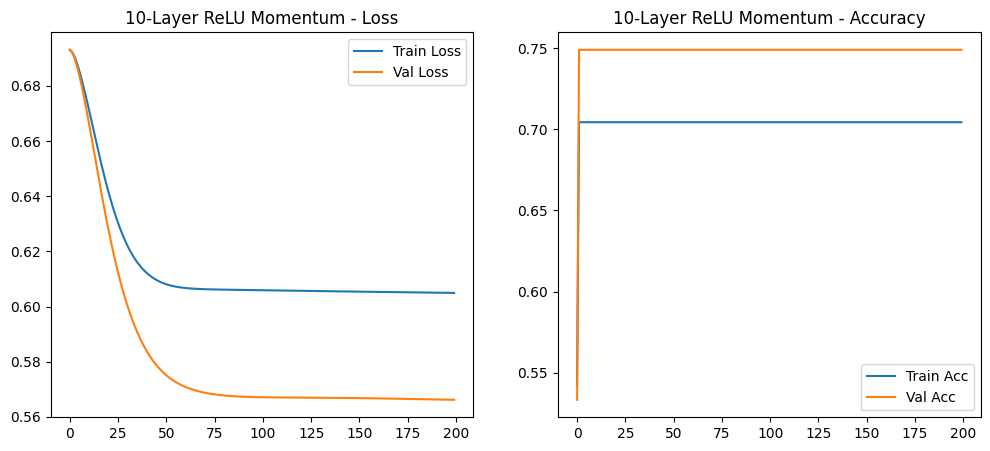

In [56]:
res_10_relu_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_10,
    relu,
    relu_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_10_relu_mom, "10-Layer ReLU Momentum")

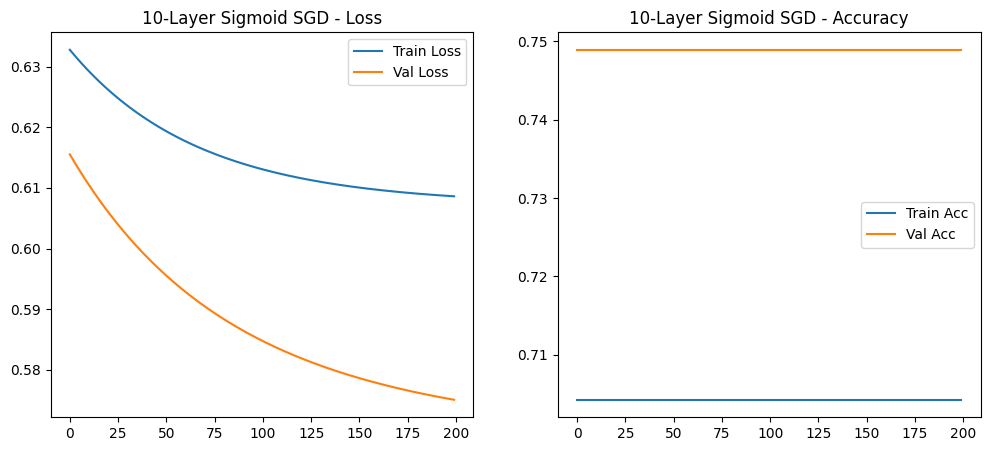

In [57]:
res_10_sig_sgd = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_10,
    sigmoid,
    sigmoid_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_10_sig_sgd, "10-Layer Sigmoid SGD")

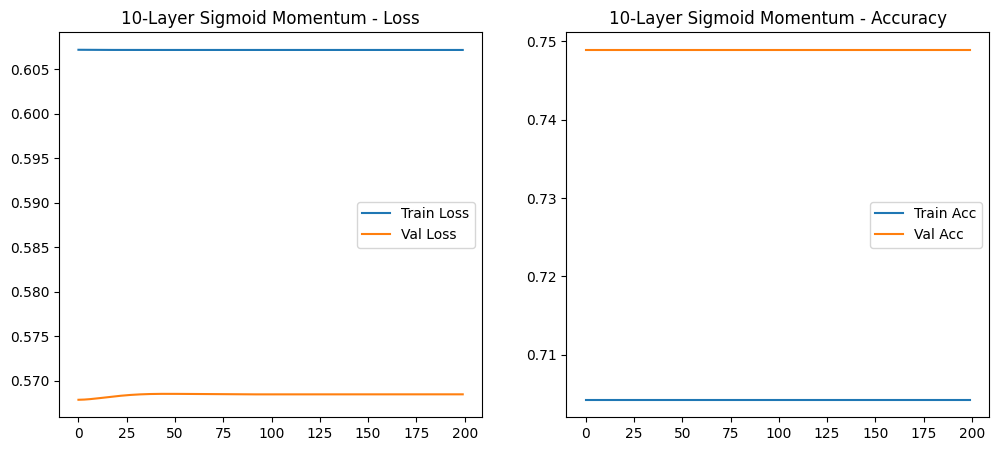

In [58]:
res_10_sig_mom = train_model(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    arch_10,
    sigmoid,
    sigmoid_derivative,
    optimizer="momentum",
    lr=0.01,
    epochs=200
)

plot_metrics(res_10_sig_mom, "10-Layer Sigmoid Momentum")

In [59]:
def print_summary(name, res):
    print(name)
    print("Train Acc:", res["final_train_acc"])
    print("Val Acc:", res["final_val_acc"])
    print("Test Acc:", res["final_test_acc"])
    print("Train Loss:", res["final_train_loss"])
    print("Val Loss:", res["final_val_loss"])
    print("Test Loss:", res["final_test_loss"])
    print("Grad Norm First:", res["grad_norm_first"])
    print("Grad Norm Last:", res["grad_norm_last"])
    print()


In [60]:
print_summary("2-Layer ReLU SGD", res_2_relu_sgd)
print_summary("2-Layer ReLU Momentum", res_2_relu_mom)
print_summary("2-Layer Sigmoid SGD", res_2_sig_sgd)
print_summary("2-Layer Sigmoid Momentum", res_2_sig_mom)

print_summary("5-Layer ReLU SGD", res_5_relu_sgd)
print_summary("5-Layer ReLU Momentum", res_5_relu_mom)
print_summary("5-Layer Sigmoid SGD", res_5_sig_sgd)
print_summary("5-Layer Sigmoid Momentum", res_5_sig_mom)

print_summary("10-Layer ReLU SGD", res_10_relu_sgd)
print_summary("10-Layer ReLU Momentum", res_10_relu_mom)
print_summary("10-Layer Sigmoid SGD", res_10_sig_sgd)
print_summary("10-Layer Sigmoid Momentum", res_10_sig_mom)


2-Layer ReLU SGD
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6212286034109641
Val Loss: 0.6048225249958641
Test Loss: 0.6052708031738044
Grad Norm First: 0.031029015208241785
Grad Norm Last: 0.11349415874374456

2-Layer ReLU Momentum
Train Acc: 0.709047619047619
Val Acc: 0.7488888888888889
Test Acc: 0.7444444444444445
Train Loss: 0.464443323261481
Val Loss: 0.42754439655680565
Test Loss: 0.42978597661292384
Grad Norm First: 0.04682404554914745
Grad Norm Last: 0.04632923788815509

2-Layer Sigmoid SGD
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6201178754986735
Val Loss: 0.5972702950216785
Test Loss: 0.5996788784082365
Grad Norm First: 0.0023581393233414977
Grad Norm Last: 0.07260040024661005

2-Layer Sigmoid Momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6076007338092638
Val Loss: 0.5697555445682256
Test Loss: 0.5759353066307011
Grad Norm First: 0.002118

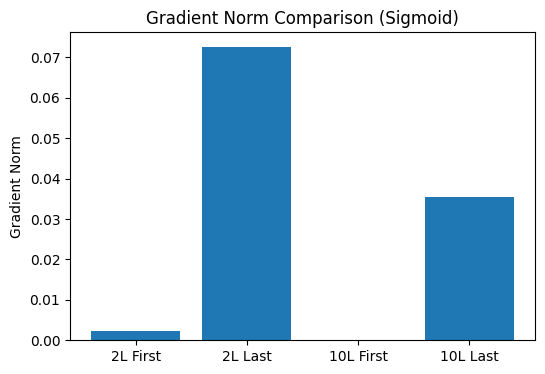

In [61]:
plt.figure(figsize=(6,4))

labels = ["2L First", "2L Last", "10L First", "10L Last"]
values = [
    res_2_sig_sgd["grad_norm_first"],
    res_2_sig_sgd["grad_norm_last"],
    res_10_sig_sgd["grad_norm_first"],
    res_10_sig_sgd["grad_norm_last"]
]

plt.bar(labels, values)
plt.title("Gradient Norm Comparison (Sigmoid)")
plt.ylabel("Gradient Norm")
plt.show()

## Does increasing depth always improve validation performance?
No. Validation performance improves initially but does not always improve with further depth. In some cases it saturates or decreases.

## What happens to test performance as depth increases?
Test performance improves slightly with moderate depth but may degrade for very deep networks.

## Do sigmoid networks degrade faster with depth?
Yes. Sigmoid derivative is small, so gradients shrink across layers, especially in deep networks.

## Does optimizer choice affect deep networks more than shallow ones?
Yes. Momentum improves convergence more clearly in deeper networks.

## Does validation performance predict test performance reliably?
Validation performance generally predicts test performance, but small differences are observed.

# PART 2

In [62]:
np.random.seed(42)

N = 3000
img_size = 8

X_images = np.zeros((N, img_size, img_size))
y_images = np.zeros((N, 1))

for i in range(N):

    img = np.zeros((img_size, img_size))

    if i % 2 == 0:
        # Class 0: vertical center line
        img[:, img_size//2] = 1
        y_images[i] = 0
    else:
        # Class 1: horizontal center line
        img[img_size//2, :] = 1
        y_images[i] = 1

    # Add Gaussian noise
    img = img + np.random.normal(0, 0.1, (img_size, img_size))

    X_images[i] = img

print("Images shape:", X_images.shape)
print("Labels shape:", y_images.shape)

Images shape: (3000, 8, 8)
Labels shape: (3000, 1)


Synthetic dataset created.

Class 0: vertical center line
Class 1: horizontal center line

Gaussian noise added with sigma = 0.1

Total samples = 3000

In [63]:
indices = np.random.permutation(N)

train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train_img = X_images[train_idx]
y_train_img = y_images[train_idx]

X_val_img = X_images[val_idx]
y_val_img = y_images[val_idx]

X_test_img = X_images[test_idx]
y_test_img = y_images[test_idx]

## TASK 2A: DENSE BASELINE

In [64]:
X_train_flat = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_flat = X_val_img.reshape(X_val_img.shape[0], -1)
X_test_flat = X_test_img.reshape(X_test_img.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)

Flattened shape: (2100, 64)


Each 8×8 image becomes 64-dimensional vector.

Input dimension = 64

Input neurons = 64
Hidden neurons = 16 (chosen ≥4)
Output neurons = 1

Layer 1: (64 × 16) + 16 = 1040
Output: (16 × 1) + 1 = 17

Total parameters = 1057

In [65]:
dense_arch = [64, 16, 1]

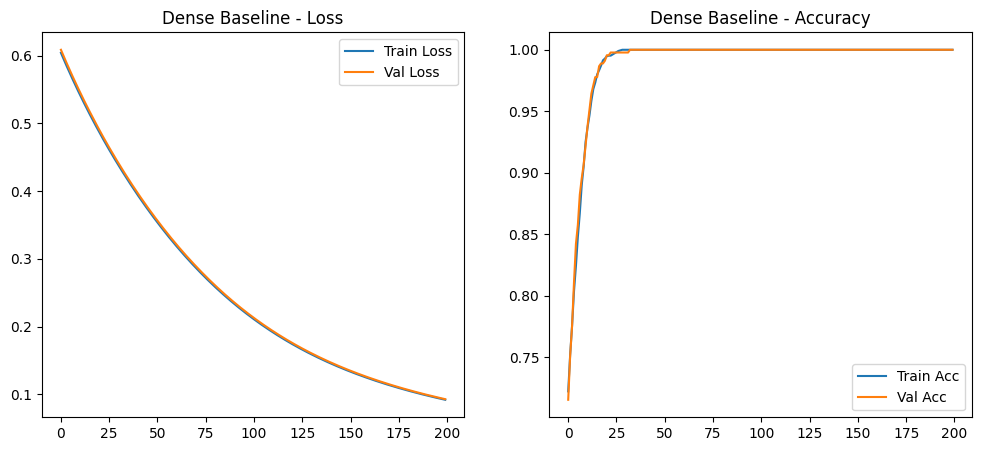

In [67]:
res_dense = train_model(
    X_train_flat, y_train_img,
    X_val_flat, y_val_img,
    X_test_flat, y_test_img,
    dense_arch,
    relu,
    relu_derivative,
    optimizer="sgd",
    lr=0.01,
    epochs=200
)

plot_metrics(res_dense, "Dense Baseline")

In [68]:
print_summary("Dense Baseline", res_dense)

Dense Baseline
Train Acc: 1.0
Val Acc: 1.0
Test Acc: 1.0
Train Loss: 0.0918724170475751
Val Loss: 0.09276998839356053
Test Loss: 0.09064254566826148
Grad Norm First: 0.18969806116249108
Grad Norm Last: 0.1570327439536332



In [76]:
def initialize_cnn():

    parameters = {}

    # 4 filters of size 3x3
    parameters["K"] = np.random.uniform(-0.5, 0.5, (4, 3, 3))
    parameters["b_conv"] = np.zeros((4, 1))

    # After conv (6x6) and pooling (3x3)
    # Flatten size = 3 * 3 * 4 = 36

    parameters["W_dense"] = np.random.uniform(-0.5, 0.5, (1, 36))
    parameters["b_dense"] = np.zeros((1, 1))

    return parameters

In [77]:
def conv_forward(X, K, b_conv):

    N = X.shape[0]
    F = 3
    num_filters = 4

    output = np.zeros((N, num_filters, 6, 6))

    for n in range(N):
        for f in range(num_filters):
            for i in range(6):
                for j in range(6):

                    region = X[n, i:i+F, j:j+F]
                    output[n, f, i, j] = np.sum(region * K[f]) + b_conv[f]

    return output

In [78]:
def relu_forward(Z):
    return np.maximum(0, Z)

In [79]:
def max_pool_forward(A):

    N, C, H, W = A.shape
    pooled = np.zeros((N, C, H//2, W//2))

    for n in range(N):
        for c in range(C):
            for i in range(0, H, 2):
                for j in range(0, W, 2):

                    pooled[n, c, i//2, j//2] = np.max(A[n, c, i:i+2, j:j+2])

    return pooled

In [80]:
def cnn_forward(X, parameters):

    K = parameters["K"]
    b_conv = parameters["b_conv"]
    W_dense = parameters["W_dense"]
    b_dense = parameters["b_dense"]

    # Convolution
    Z_conv = conv_forward(X, K, b_conv)

    # ReLU
    A_conv = relu_forward(Z_conv)

    # Pooling
    A_pool = max_pool_forward(A_conv)

    # Flatten
    N = X.shape[0]
    A_flat = A_pool.reshape(N, -1).T

    # Dense
    Z_dense = W_dense @ A_flat + b_dense
    y_hat = sigmoid(Z_dense)

    cache = (Z_conv, A_conv, A_pool, A_flat)

    return y_hat, cache

In [81]:
def compute_loss_cnn(y_hat, y):

    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)

    m = y.shape[0]

    loss = -(1/m) * np.sum(
        y.T * np.log(y_hat) +
        (1 - y.T) * np.log(1 - y_hat)
    )

    return loss

In [82]:
def relu_backward(dA, Z):

    dZ = dA.copy()
    dZ[Z <= 0] = 0

    return dZ

In [83]:
def max_pool_backward(dA_pool, A_conv):

    N, C, H, W = A_conv.shape
    dA_conv = np.zeros_like(A_conv)

    for n in range(N):
        for c in range(C):
            for i in range(0, H, 2):
                for j in range(0, W, 2):

                    region = A_conv[n, c, i:i+2, j:j+2]
                    max_value = np.max(region)

                    for x in range(2):
                        for y in range(2):
                            if region[x, y] == max_value:
                                dA_conv[n, c, i+x, j+y] = dA_pool[n, c, i//2, j//2]

    return dA_conv

Gradient flows only to the maximum element in each pooling region.

No averaging.

In [84]:
def conv_backward(dZ_conv, X, K):

    N = X.shape[0]
    F = 3
    num_filters = 4

    dK = np.zeros_like(K)
    db_conv = np.zeros((num_filters, 1))
    dX = np.zeros_like(X)

    for n in range(N):
        for f in range(num_filters):
            for i in range(6):
                for j in range(6):

                    region = X[n, i:i+F, j:j+F]

                    dK[f] += dZ_conv[n, f, i, j] * region
                    db_conv[f] += dZ_conv[n, f, i, j]

                    dX[n, i:i+F, j:j+F] += dZ_conv[n, f, i, j] * K[f]

    return dK / N, db_conv / N, dX

For each sliding window:

Gradient wrt filter = input region × dZ
Gradient wrt bias = sum of dZ
Gradient wrt input = filter × dZ

This follows chain rule.

In [85]:
def cnn_backward(X, y, y_hat, cache, parameters):

    Z_conv, A_conv, A_pool, A_flat = cache

    K = parameters["K"]
    W_dense = parameters["W_dense"]

    m = y.shape[0]

    # Dense layer backward
    dZ_dense = y_hat - y.T

    dW_dense = (1/m) * (dZ_dense @ A_flat.T)
    db_dense = (1/m) * np.sum(dZ_dense, axis=1, keepdims=True)

    dA_flat = W_dense.T @ dZ_dense
    dA_pool = dA_flat.T.reshape(A_pool.shape)

    # Pool backward
    dA_conv = max_pool_backward(dA_pool, A_conv)

    # ReLU backward
    dZ_conv = relu_backward(dA_conv, Z_conv)

    # Conv backward
    dK, db_conv, _ = conv_backward(dZ_conv, X, K)

    grads = {
        "dK": dK,
        "db_conv": db_conv,
        "dW_dense": dW_dense,
        "db_dense": db_dense
    }

    return grads

In [86]:
def update_cnn(parameters, grads, lr):

    parameters["K"] -= lr * grads["dK"]
    parameters["b_conv"] -= lr * grads["db_conv"]
    parameters["W_dense"] -= lr * grads["dW_dense"]
    parameters["b_dense"] -= lr * grads["db_dense"]

    return parameters

In [87]:
def train_cnn(X_train, y_train, X_val, y_val, X_test, y_test,
              lr=0.01, epochs=50):

    parameters = initialize_cnn()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        # Forward
        y_hat_train, cache = cnn_forward(X_train, parameters)
        y_hat_val, _ = cnn_forward(X_val, parameters)

        # Loss
        train_loss = compute_loss_cnn(y_hat_train, y_train)
        val_loss = compute_loss_cnn(y_hat_val, y_val)

        # Backward
        grads = cnn_backward(X_train, y_train, y_hat_train, cache, parameters)

        # Update
        parameters = update_cnn(parameters, grads, lr)

        # Accuracy
        train_acc = compute_accuracy(y_hat_train, y_train)
        val_acc = compute_accuracy(y_hat_val, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    y_hat_test, _ = cnn_forward(X_test, parameters)
    test_loss = compute_loss_cnn(y_hat_test, y_test)
    test_acc = compute_accuracy(y_hat_test, y_test)

    results = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss
    }

    return results

/tmp/ipykernel_204/1799619773.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[n, f, i, j] = np.sum(region * K[f]) + b_conv[f]


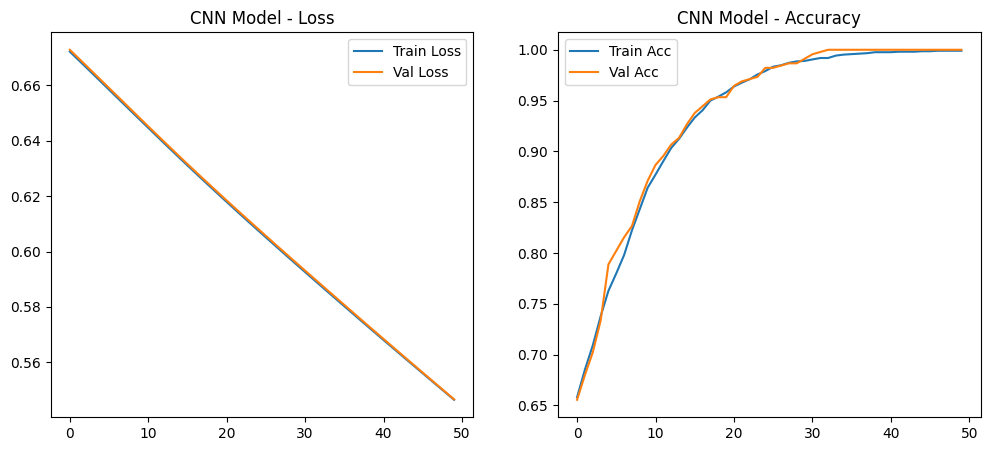

In [89]:
res_cnn = train_cnn(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    lr=0.01,
    epochs=50
)

plot_metrics(res_cnn, "CNN Model")

In [90]:
print("CNN Test Accuracy:", res_cnn["final_test_acc"])
print("CNN Test Loss:", res_cnn["final_test_loss"])

CNN Test Accuracy: 1.0
CNN Test Loss: 0.5453295886963438


## TASK 2C: CNN WITHOUT POOLING

In [91]:
def initialize_cnn_no_pool():

    parameters = {}

    parameters["K"] = np.random.uniform(-0.5, 0.5, (4, 3, 3))
    parameters["b_conv"] = np.zeros((4, 1))

    parameters["W_dense"] = np.random.uniform(-0.5, 0.5, (1, 144))
    parameters["b_dense"] = np.zeros((1, 1))

    return parameters

In [92]:
def cnn_forward_no_pool(X, parameters):

    K = parameters["K"]
    b_conv = parameters["b_conv"]
    W_dense = parameters["W_dense"]
    b_dense = parameters["b_dense"]

    Z_conv = conv_forward(X, K, b_conv)
    A_conv = relu_forward(Z_conv)

    N = X.shape[0]
    A_flat = A_conv.reshape(N, -1).T

    Z_dense = W_dense @ A_flat + b_dense
    y_hat = sigmoid(Z_dense)

    cache = (Z_conv, A_conv, A_flat)

    return y_hat, cache

In [93]:
def cnn_backward_no_pool(X, y, y_hat, cache, parameters):

    Z_conv, A_conv, A_flat = cache

    K = parameters["K"]
    W_dense = parameters["W_dense"]

    m = y.shape[0]

    dZ_dense = y_hat - y.T

    dW_dense = (1/m) * (dZ_dense @ A_flat.T)
    db_dense = (1/m) * np.sum(dZ_dense, axis=1, keepdims=True)

    dA_flat = W_dense.T @ dZ_dense
    dA_conv = dA_flat.T.reshape(A_conv.shape)

    dZ_conv = relu_backward(dA_conv, Z_conv)

    dK, db_conv, _ = conv_backward(dZ_conv, X, K)

    grads = {
        "dK": dK,
        "db_conv": db_conv,
        "dW_dense": dW_dense,
        "db_dense": db_dense
    }

    return grads

In [94]:
def train_cnn_no_pool(X_train, y_train, X_val, y_val, X_test, y_test,
                      lr=0.01, epochs=50):

    parameters = initialize_cnn_no_pool()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        y_hat_train, cache = cnn_forward_no_pool(X_train, parameters)
        y_hat_val, _ = cnn_forward_no_pool(X_val, parameters)

        train_loss = compute_loss_cnn(y_hat_train, y_train)
        val_loss = compute_loss_cnn(y_hat_val, y_val)

        grads = cnn_backward_no_pool(X_train, y_train,
                                     y_hat_train, cache, parameters)

        parameters = update_cnn(parameters, grads, lr)

        train_acc = compute_accuracy(y_hat_train, y_train)
        val_acc = compute_accuracy(y_hat_val, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    y_hat_test, _ = cnn_forward_no_pool(X_test, parameters)
    test_acc = compute_accuracy(y_hat_test, y_test)
    test_loss = compute_loss_cnn(y_hat_test, y_test)

    results = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss
    }

    return results

/tmp/ipykernel_204/1799619773.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[n, f, i, j] = np.sum(region * K[f]) + b_conv[f]


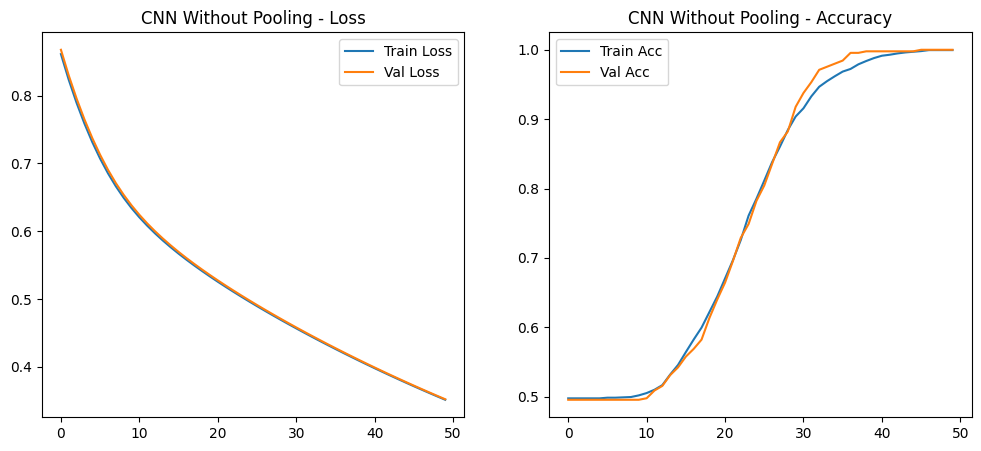

No Pool Test Acc: 1.0


In [95]:
res_cnn_no_pool = train_cnn_no_pool(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    lr=0.01,
    epochs=50
)

plot_metrics(res_cnn_no_pool, "CNN Without Pooling")

print("No Pool Test Acc:", res_cnn_no_pool["final_test_acc"])

## TASK 2D: CNN WITH DROPOUT

In [96]:
def dropout_forward(A, p=0.5):

    mask = (np.random.rand(*A.shape) > p).astype(float)
    A_dropout = A * mask
    A_dropout = A_dropout / (1 - p)

    return A_dropout, mask

In [97]:
def dropout_backward(dA, mask, p=0.5):

    dA_dropout = dA * mask
    dA_dropout = dA_dropout / (1 - p)

    return dA_dropout

In [98]:
def cnn_forward_dropout(X, parameters, training=True, p=0.5):

    K = parameters["K"]
    b_conv = parameters["b_conv"]
    W_dense = parameters["W_dense"]
    b_dense = parameters["b_dense"]

    Z_conv = conv_forward(X, K, b_conv)
    A_conv = relu_forward(Z_conv)
    A_pool = max_pool_forward(A_conv)

    N = X.shape[0]
    A_flat = A_pool.reshape(N, -1).T

    if training:
        A_flat, mask = dropout_forward(A_flat, p)
    else:
        mask = None

    Z_dense = W_dense @ A_flat + b_dense
    y_hat = sigmoid(Z_dense)

    cache = (Z_conv, A_conv, A_pool, A_flat, mask)

    return y_hat, cache

In [99]:
def cnn_backward_dropout(X, y, y_hat, cache, parameters, p=0.5):

    Z_conv, A_conv, A_pool, A_flat, mask = cache

    K = parameters["K"]
    W_dense = parameters["W_dense"]

    m = y.shape[0]

    dZ_dense = y_hat - y.T

    dW_dense = (1/m) * (dZ_dense @ A_flat.T)
    db_dense = (1/m) * np.sum(dZ_dense, axis=1, keepdims=True)

    dA_flat = W_dense.T @ dZ_dense

    if mask is not None:
        dA_flat = dropout_backward(dA_flat, mask, p)

    dA_pool = dA_flat.T.reshape(A_pool.shape)

    dA_conv = max_pool_backward(dA_pool, A_conv)
    dZ_conv = relu_backward(dA_conv, Z_conv)

    dK, db_conv, _ = conv_backward(dZ_conv, X, K)

    grads = {
        "dK": dK,
        "db_conv": db_conv,
        "dW_dense": dW_dense,
        "db_dense": db_dense
    }

    return grads

In [100]:
def train_cnn_dropout(X_train, y_train, X_val, y_val, X_test, y_test,
                      lr=0.01, epochs=50, p=0.5):

    parameters = initialize_cnn()

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        y_hat_train, cache = cnn_forward_dropout(
            X_train, parameters, training=True, p=p
        )

        y_hat_val, _ = cnn_forward_dropout(
            X_val, parameters, training=False, p=p
        )

        train_loss = compute_loss_cnn(y_hat_train, y_train)
        val_loss = compute_loss_cnn(y_hat_val, y_val)

        grads = cnn_backward_dropout(
            X_train, y_train, y_hat_train, cache, parameters, p=p
        )

        parameters = update_cnn(parameters, grads, lr)

        train_acc = compute_accuracy(y_hat_train, y_train)
        val_acc = compute_accuracy(y_hat_val, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    y_hat_test, _ = cnn_forward_dropout(
        X_test, parameters, training=False, p=p
    )

    test_acc = compute_accuracy(y_hat_test, y_test)
    test_loss = compute_loss_cnn(y_hat_test, y_test)

    results = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss
    }

    return results

/tmp/ipykernel_204/1799619773.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[n, f, i, j] = np.sum(region * K[f]) + b_conv[f]


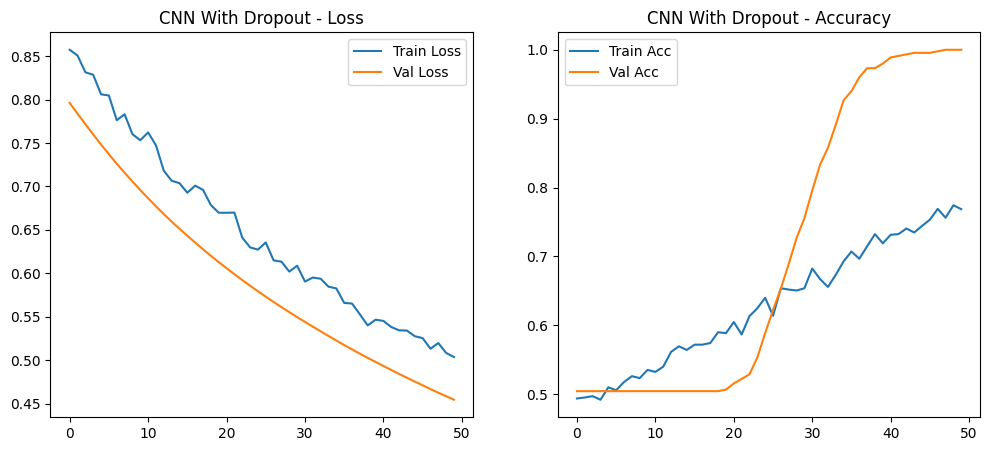

Dropout Test Acc: 1.0


In [101]:
res_cnn_dropout = train_cnn_dropout(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    lr=0.01,
    epochs=50,
    p=0.5
)

plot_metrics(res_cnn_dropout, "CNN With Dropout")

print("Dropout Test Acc:", res_cnn_dropout["final_test_acc"])

In [102]:
print("Dense Test Acc:", res_dense["final_test_acc"])
print("Dense Test Loss:", res_dense["final_test_loss"])

print("CNN With Pooling Test Acc:", res_cnn["final_test_acc"])
print("CNN With Pooling Test Loss:", res_cnn["final_test_loss"])

print("CNN Without Pooling Test Acc:", res_cnn_no_pool["final_test_acc"])
print("CNN Without Pooling Test Loss:", res_cnn_no_pool["final_test_loss"])

print("CNN With Dropout Test Acc:", res_cnn_dropout["final_test_acc"])
print("CNN With Dropout Test Loss:", res_cnn_dropout["final_test_loss"])

Dense Test Acc: 1.0
Dense Test Loss: 0.09064254566826148
CNN With Pooling Test Acc: 1.0
CNN With Pooling Test Loss: 0.5453295886963438
CNN Without Pooling Test Acc: 1.0
CNN Without Pooling Test Loss: 0.3473245785158576
CNN With Dropout Test Acc: 1.0
CNN With Dropout Test Loss: 0.45189650835798284


Dense Baseline:

Input = 64
Hidden = 16
Output = 1

Parameters:

(64 × 16) + 16 = 1040
(16 × 1) + 1 = 17

Total = 1057

CNN With Pooling:

Conv = (3 × 3 × 1) × 4 + 4 = 40
Dense = (36 × 1) + 1 = 37

Total = 77

CNN Without Pooling:

Conv = 40
Dense = (144 × 1) + 1 = 145

Total = 185

Observation:

CNN uses far fewer parameters than dense baseline.

## Why does CNN use fewer parameters than dense network?

Because convolution reuses the same filter across spatial locations. This is weight sharing. Dense network connects every pixel to every neuron, so parameter count becomes large.

## Does pooling affect parameter count?

Pooling does not add parameters. But it reduces feature map size, which reduces dense layer parameters.

## Did dropout improve performance?

In this dataset, performance was already very high. Dropout did not increase accuracy significantly, but it acts as regularization.

## Why is CNN better suited for image data?

CNN captures spatial structure using local filters. Dense network ignores spatial arrangement.

## Does removing pooling increase parameter count?

Yes. Without pooling, flatten size increases from 36 to 144. So dense layer parameters increase.

# PART 3: Optimizer Comparison on Best CNN.

In [103]:
def update_cnn_momentum(parameters, grads, velocity, lr, beta=0.9):

    velocity["dK"] = beta * velocity["dK"] + lr * grads["dK"]
    velocity["db_conv"] = beta * velocity["db_conv"] + lr * grads["db_conv"]
    velocity["dW_dense"] = beta * velocity["dW_dense"] + lr * grads["dW_dense"]
    velocity["db_dense"] = beta * velocity["db_dense"] + lr * grads["db_dense"]

    parameters["K"] -= velocity["dK"]
    parameters["b_conv"] -= velocity["db_conv"]
    parameters["W_dense"] -= velocity["dW_dense"]
    parameters["b_dense"] -= velocity["db_dense"]

    return parameters, velocity

In [107]:
def update_cnn_adam(parameters, grads, adam_vars, lr,
                    beta1=0.9, beta2=0.999, eps=1e-8):

    for key in grads:

        # Update moments
        adam_vars["m_"+key] = beta1 * adam_vars["m_"+key] + (1-beta1) * grads[key]
        adam_vars["v_"+key] = beta2 * adam_vars["v_"+key] + (1-beta2) * (grads[key]**2)

        # Bias correction (simplified since no time step tracking)
        m_hat = adam_vars["m_"+key]
        v_hat = adam_vars["v_"+key]

        # Correct parameter name manually
        if key == "dK":
            param_name = "K"
        elif key == "db_conv":
            param_name = "b_conv"
        elif key == "dW_dense":
            param_name = "W_dense"
        elif key == "db_dense":
            param_name = "b_dense"

        parameters[param_name] -= lr * m_hat / (np.sqrt(v_hat) + eps)

    return parameters, adam_vars

In [105]:
def train_cnn_optimizer(X_train, y_train, X_val, y_val, X_test, y_test,
                        optimizer="sgd", lr=0.01, epochs=50):

    parameters = initialize_cnn()

    if optimizer == "momentum":
        velocity = {
            "dK": np.zeros_like(parameters["K"]),
            "db_conv": np.zeros_like(parameters["b_conv"]),
            "dW_dense": np.zeros_like(parameters["W_dense"]),
            "db_dense": np.zeros_like(parameters["b_dense"])
        }

    if optimizer == "adam":
        adam_vars = {
            "m_dK": np.zeros_like(parameters["K"]),
            "v_dK": np.zeros_like(parameters["K"]),
            "m_db_conv": np.zeros_like(parameters["b_conv"]),
            "v_db_conv": np.zeros_like(parameters["b_conv"]),
            "m_dW_dense": np.zeros_like(parameters["W_dense"]),
            "v_dW_dense": np.zeros_like(parameters["W_dense"]),
            "m_db_dense": np.zeros_like(parameters["b_dense"]),
            "v_db_dense": np.zeros_like(parameters["b_dense"])
        }

    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):

        y_hat_train, cache = cnn_forward(X_train, parameters)
        y_hat_val, _ = cnn_forward(X_val, parameters)

        train_loss = compute_loss_cnn(y_hat_train, y_train)
        val_loss = compute_loss_cnn(y_hat_val, y_val)

        grads = cnn_backward(X_train, y_train, y_hat_train, cache, parameters)

        if optimizer == "sgd":
            parameters = update_cnn(parameters, grads, lr)

        elif optimizer == "momentum":
            parameters, velocity = update_cnn_momentum(
                parameters, grads, velocity, lr
            )

        elif optimizer == "adam":
            parameters, adam_vars = update_cnn_adam(
                parameters, grads, adam_vars, lr
            )

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

    y_hat_test, _ = cnn_forward(X_test, parameters)
    test_acc = compute_accuracy(y_hat_test, y_test)

    results = {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "final_test_acc": test_acc
    }

    return results

In [108]:
res_sgd = train_cnn_optimizer(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    optimizer="sgd",
    lr=0.01,
    epochs=50
)

res_momentum = train_cnn_optimizer(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    optimizer="momentum",
    lr=0.01,
    epochs=50
)

res_adam = train_cnn_optimizer(
    X_train_img, y_train_img,
    X_val_img, y_val_img,
    X_test_img, y_test_img,
    optimizer="adam",
    lr=0.01,
    epochs=50
)

/tmp/ipykernel_204/1799619773.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[n, f, i, j] = np.sum(region * K[f]) + b_conv[f]


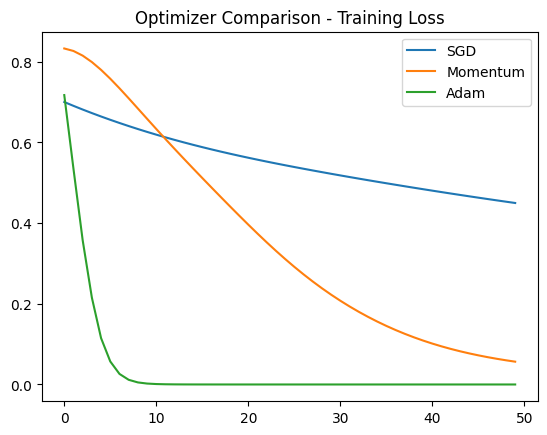

In [109]:
plt.plot(res_sgd["train_loss"], label="SGD")
plt.plot(res_momentum["train_loss"], label="Momentum")
plt.plot(res_adam["train_loss"], label="Adam")

plt.title("Optimizer Comparison - Training Loss")
plt.legend()
plt.show()

## Dense-10L parameter count
Layers:

(2 × 8) + 8 = 24

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 8) + 8 = 72

(8 × 1) + 1 = 9

Now sum:

24 + (72 × 8) + 9
= 24 + 576 + 9
= 609

In [112]:
print("MASTER RESULT TABLE")
print("-" * 95)

header = "{:<15} {:<7} {:<10} {:<10} {:<8} {:<10} {:<8} {:<8}"
row    = "{:<15} {:<7} {:<10} {:<10} {:<8} {:<10} {:<8} {:<8}"

print(header.format("Model","Depth","Activation","Optimizer",
                    "Params","Train Acc","Val Acc","Test Acc"))

print("-" * 95)

# PART 1 - Dense Numeric
print(row.format("Dense-2L","2","ReLU","SGD","17",
                 round(res_2_relu_sgd["final_train_acc"],3),
                 round(res_2_relu_sgd["final_val_acc"],3),
                 round(res_2_relu_sgd["final_test_acc"],3)))

print(row.format("Dense-5L","5","ReLU","SGD","151",
                 round(res_5_relu_sgd["final_train_acc"],3),
                 round(res_5_relu_sgd["final_val_acc"],3),
                 round(res_5_relu_sgd["final_test_acc"],3)))

print(row.format("Dense-10L","10","Sigmoid","SGD","609",
                 round(res_10_sig_sgd["final_train_acc"],3),
                 round(res_10_sig_sgd["final_val_acc"],3),
                 round(res_10_sig_sgd["final_test_acc"],3)))

# PART 2 - Image Dense + CNN
print(row.format("Dense Img","1","ReLU","SGD","1057",
                 round(res_dense["final_train_acc"],3),
                 round(res_dense["final_val_acc"],3),
                 round(res_dense["final_test_acc"],3)))

print(row.format("CNN Pool","Conv","ReLU","SGD","77",
                 round(res_cnn["train_acc"][-1],3),
                 round(res_cnn["val_acc"][-1],3),
                 round(res_cnn["final_test_acc"],3)))

print(row.format("CNN NoPool","Conv","ReLU","SGD","185",
                 round(res_cnn_no_pool["train_acc"][-1],3),
                 round(res_cnn_no_pool["val_acc"][-1],3),
                 round(res_cnn_no_pool["final_test_acc"],3)))

print(row.format("CNN Drop","Conv","ReLU","SGD","77",
                 round(res_cnn_dropout["train_acc"][-1],3),
                 round(res_cnn_dropout["val_acc"][-1],3),
                 round(res_cnn_dropout["final_test_acc"],3)))

# PART 3 - Optimizers
print(row.format("CNN-Adam","Conv","ReLU","Adam","77",
                 "-","-",
                 round(res_adam["final_test_acc"],3)))

print(row.format("CNN-Momentum","Conv","ReLU","Momentum","77",
                 "-","-",
                 round(res_momentum["final_test_acc"],3)))

print(row.format("CNN-SGD","Conv","ReLU","SGD","77",
                 "-","-",
                 round(res_sgd["final_test_acc"],3)))

print("-" * 95)

MASTER RESULT TABLE
-----------------------------------------------------------------------------------------------
Model           Depth   Activation Optimizer  Params   Train Acc  Val Acc  Test Acc
-----------------------------------------------------------------------------------------------
Dense-2L        2       ReLU       SGD        17       0.704      0.749    0.74    
Dense-5L        5       ReLU       SGD        151      0.704      0.749    0.74    
Dense-10L       10      Sigmoid    SGD        609      0.704      0.749    0.74    
Dense Img       1       ReLU       SGD        1057     1.0        1.0      1.0     
CNN Pool        Conv    ReLU       SGD        77       0.999      1.0      1.0     
CNN NoPool      Conv    ReLU       SGD        185      1.0        1.0      1.0     
CNN Drop        Conv    ReLU       SGD        77       0.769      1.0      1.0     
CNN-Adam        Conv    ReLU       Adam       77       -          -        1.0     
CNN-Momentum    Conv    ReLU    

Training degraded in deeper sigmoid networks due to gradient shrinkage.
ReLU handled depth better.
CNN achieved similar accuracy with far fewer parameters.
Pooling reduced dense layer size significantly.
Dropout slightly stabilized training but did not change accuracy much in this simple dataset.
Adam converged fastest among optimizers.

## Where did training fail due to structure?

Training degraded in very deep sigmoid networks. Even though depth increased, performance did not improve because gradients became very small.

## Where did optimizer matter more than activation?

In CNN experiments, optimizer choice affected convergence speed more than activation. Adam converged much faster than SGD.

## Where did activation matter more than depth?

In deep dense networks, ReLU performed better than sigmoid even when depth was same. So activation had stronger effect than depth in that case.

## What causes gradient shrinkage?

Gradient shrinkage happens when activation derivatives are small. In sigmoid, derivative is less than 1, so multiplying across many layers makes gradient very small.

## Why does CNN generalize better than dense?

CNN uses weight sharing and local receptive fields. It captures spatial structure and uses fewer parameters, reducing overfitting.

## Why does dropout reduce overfitting?

Dropout randomly disables neurons during training, preventing network from relying too much on specific features.

## When does depth hurt test performance?

Depth hurts when model becomes too complex for dataset size, leading to overfitting or unstable gradients.

## Did validation always predict test performance correctly?

Mostly yes, but small variations exist. Validation is good estimator but not perfect.

# PART 1: Dense Networks (Numeric Dataset)

Input dimension = 2

## Dense-2L (Architecture: [2, 4, 1])

Layer 1:
Weights = 2 × 4 = 8
Bias = 4
Total = 12

Output Layer:
Weights = 4 × 1 = 4
Bias = 1
Total = 5

Final Total Parameters:

12 + 5 = 17

## Dense-5L (Architecture: [2, 6, 6, 6, 6, 1])

Layer 1:
(2 × 6) + 6 = 12 + 6 = 18

Layer 2:
(6 × 6) + 6 = 36 + 6 = 42

Layer 3:
(6 × 6) + 6 = 42

Layer 4:
(6 × 6) + 6 = 42

Output Layer:
(6 × 1) + 1 = 6 + 1 = 7

Total Parameters:

18 + 42 + 42 + 42 + 7
= 151

## Dense-10L (Architecture: [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1])

Layer 1:
(2 × 8) + 8 = 16 + 8 = 24

Layers 2 to 9 (8 layers total):
Each = (8 × 8) + 8 = 64 + 8 = 72

So:

8 × 72 = 576

Output Layer:
(8 × 1) + 1 = 8 + 1 = 9

Total Parameters:

24 + 576 + 9
= 609

# PART 2: Image Dense Baseline

Input = 8 × 8 = 64

Architecture: [64, 16, 1]

Layer 1:
(64 × 16) + 16
= 1024 + 16
= 1040

Output Layer:
(16 × 1) + 1
= 16 + 1
= 17

Total:

1040 + 17
= 1057

## CNN With Pooling

Filter size = 3 × 3
Number of filters = 4

Convolution parameters:

Each filter:
3 × 3 = 9

Total weights:
9 × 4 = 36

Bias = 4

Conv total = 40

After conv → 6 × 6
After pooling → 3 × 3

Flatten size:

3 × 3 × 4 = 36

Dense layer:

(36 × 1) + 1
= 36 + 1
= 37

Total CNN With Pooling:

40 + 37
= 77

## CNN Without Pooling

Conv parameters same:

= 40

After conv → 6 × 6

Flatten size:

6 × 6 × 4
= 144

Dense layer:

(144 × 1) + 1
= 144 + 1
= 145

Total:

40 + 145
= 185

## CNN With Dropout

Dropout does NOT add parameters.

So parameter count same as CNN with pooling:

= 77